In [2]:
# from adjustText import adjust_text
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
today = datetime.today().strftime('%Y-%m-%d')

from module.config_local import dir_processed


# DEG

## Data import DEG celltype

In [3]:
name_dir = 'all-samples-combined'
control = "WT"
test = "APP"


# name_dir = "all-samples-combined"
# control = "WT"
# test = "APP"

df_all = pd.read_excel(f'{dir_processed}/analysis/{name_dir}/foldchanges/cell_type_final/DEG_cell_type_final_no-filter.xlsx', sheet_name=None)
df_expressed = {}
for key in df_all.keys():
    if control in df_all[key]["group"].unique():
        df_all[key] = df_all[key][df_all[key]['group'] == test]
    df_expressed[key] = df_all[key][
            (df_all[key]['pct_nz_group']>0.1) &
          (df_all[key]['mean_count']>= 0.2)
          ]
    df_all[key].index = df_all[key]['names']

In [4]:
### Alternative filtering
df_filter = {}
for key in df_all.keys():
    df_filter[key] = df_all[key][(df_all[key]['pvals_adj'] < 0.05)
                                 & (df_all[key]['pct_nz_group'] >= 0.1)
                                 & (df_all[key]['pct_nz_reference'] >= 0.1)
                                 & (abs(df_all[key]['logfoldchanges']) > 0.26)
                                 & (df_all[key]['mean_count'] >=0.2)
                                 ]
# df_filter['SCH_Gaba'].sort_values(by='logfoldchanges',ascending=False)

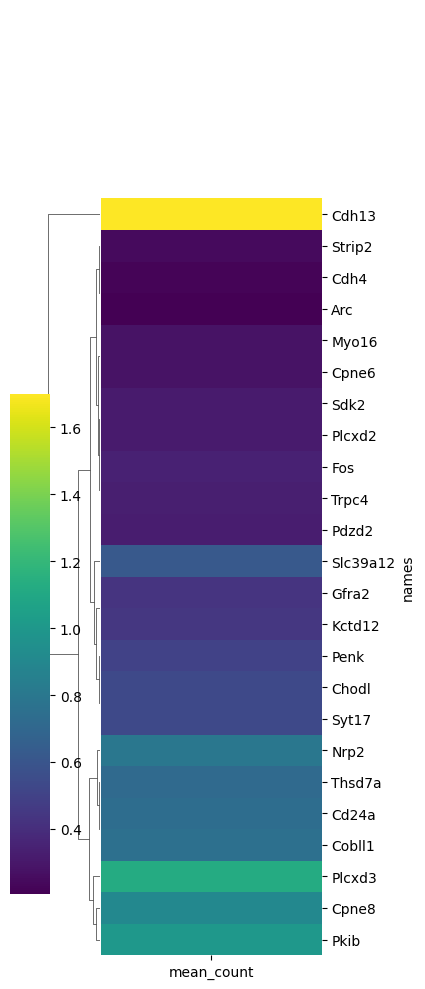

In [19]:
df_filter_sec = df_filter['SCH_Gaba'].filter(['names','mean_count'])
df_filter_sec.drop('names',axis=1, inplace=True)
sns.clustermap(df_filter_sec, cmap = 'viridis',# z_score=1,  center=0, vmin = -2, vmax = 2,
                col_cluster=False,row_cluster=True, cbar = 'upper left', cbar_pos=(-0.05,0.1,0.1,0.5),figsize=(4, 10),
                )

In [ ]:
df_filter.pop('')
len(df_filter.keys())

77

### Distribution of number of DEG and top DEG

In [12]:
list_of_DEG = []
for key in df_filter:
    list_temp = list(df_filter[key]['names'])
    list_of_DEG.extend(list_temp)

In [13]:
unique_gene = set(list_of_DEG)
count_dict = {}
for gene in unique_gene:
    count_dict[gene] = list_of_DEG.count(gene)

In [14]:
df = pd.DataFrame(data ={"Gene": list(unique_gene)})

In [15]:
df['count'] = df['Gene'].map(count_dict)
df.sort_values(by='count', inplace = True, ascending = False)
df.shape

(237, 2)

Text(0.5, 0, 'Number of celltypes')

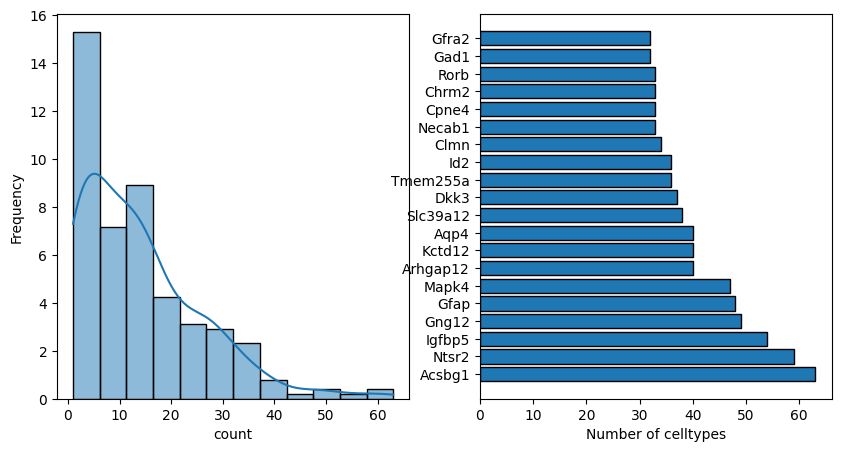

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax = ax.flatten()
ax[1].barh(y=df['Gene'][0:20], height=0.8, width=df['count'][0:20], edgecolor = 'black')
# plt.hist(x=df['count'])
sns.histplot(df['count'], element="bars", cumulative= False, fill= True, common_norm=False,kde = True,
             stat='frequency', ax=ax[0])
plt.xlabel('Number of celltypes')
# plt.yscale("log")

In [17]:
from module.misc import cell_class
dict_cellclass = cell_class()

list_of_celltype = [key for key in df_filter.keys()]
df_celltype = pd.DataFrame(data = {'Celltype' : list_of_celltype})
df_celltype['Cellclass'] = df_celltype['Celltype'].apply(lambda x: dict_cellclass[x] if x in dict_cellclass.keys() else "Neuron")
df_celltype.sample(5)

,Celltype,Cellclass
41,STR_D2_Gaba,Neuron
23,STR_PAL_Gaba,Neuron
22,Lamp5_Gaba,Neuron
62,CA2_Glut,Neuron
0,VMH_Glut,Neuron


In [18]:
from module.misc import genes_list
import numpy as np

gene_index = genes_list('brain_panel')

matrix = pd.DataFrame(data = {'Neuron':np.zeros(len(gene_index)),
                              "Glial" : np.zeros(len(gene_index)),
                              'Vascular': np.zeros(len(gene_index)),
                              'Ependymal': np.zeros(len(gene_index))}, index = gene_index)

class_list = df_celltype.groupby('Cellclass')['Celltype'].unique()

for nb, class_ in enumerate(class_list):
    class_for_matrix = class_list.index[nb]
    for celltype_ in class_:
        list_temp = list(df_filter[celltype_]['names'])
        for gene in list_temp:
            matrix.loc[gene,class_for_matrix] += 1


matrix['total'] = matrix.sum(axis=1)
matrix.sort_values(by='total', ascending = False, inplace= True)

Text(0.5, 0, 'Number of celltypes')

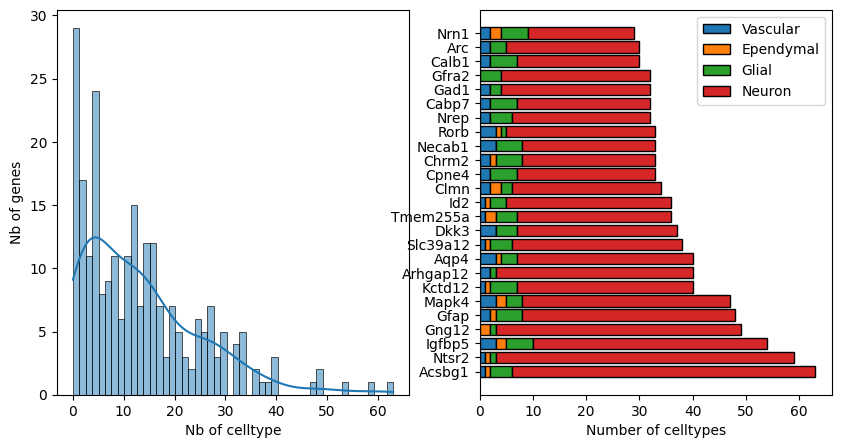

In [19]:
y1 = matrix['Vascular'][0:25]
y2 = matrix['Ependymal'][0:25]
y3 = matrix['Glial'][0:25]
y4 = matrix['Neuron'][0:25]

import seaborn as sns
fig, ax = plt.subplots(1,2, figsize=(10,5))
ax = ax.flatten()

# plt.hist(x=df['count'])
sns.histplot(matrix['total'], element="bars", cumulative= False, fill= True, bins=50,
             common_norm=False, kde = True,
             stat='count', ax=ax[0])
ax[0].set_ylabel('Nb of genes')
ax[0].set_xlabel('Nb of celltype')

# ax[0].hist(x=matrix['total'])


ax[1].barh(y=matrix.index[0:25], height=0.8, width=y1, edgecolor = 'black', label = "Vascular")
ax[1].barh(y=matrix.index[0:25], height=0.8, width=y2, left = y1,  edgecolor = 'black', label = "Ependymal")
ax[1].barh(y=matrix.index[0:25], height=0.8, width=y3, left = y1+y2,  edgecolor = 'black',label = "Glial")
ax[1].barh(y=matrix.index[0:25], height=0.8, width=y4, left = y1+y2+y3,  edgecolor = 'black', label = "Neuron")
ax[1].legend()
ax[1].set_xlabel('Number of celltypes')

# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y1b, edgecolor = 'black', label = "Vascular")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y2b, left = y1b,  edgecolor = 'black', label = "Ependymal")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y3b, left = y1b+y2b,  edgecolor = 'black',label = "Glial")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y4b, left = y1b+y2b+y3b,  edgecolor = 'black', label = "Neuron")
# ax[2].legend()
# ax[2].set_xlabel('Number of celltypes')

# plt.savefig(f'Gallery/{today}/DEG_distribution.svg', dpi = 300)



In [20]:
matrix_bis = matrix[matrix['total']!=0]
matrix_bis.head()

,Neuron,Glial,Vascular,Ependymal,total
Acsbg1,57.0,4.0,1.0,1.0,63.0
Ntsr2,56.0,1.0,1.0,1.0,59.0
Igfbp5,44.0,5.0,3.0,2.0,54.0
Gng12,46.0,1.0,0.0,2.0,49.0
Gfap,40.0,5.0,2.0,1.0,48.0


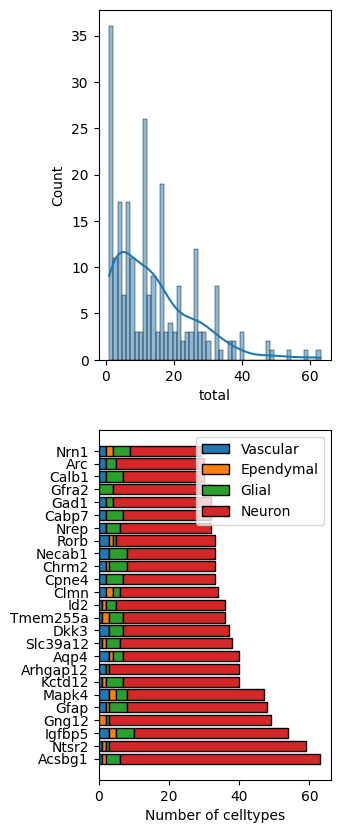

In [22]:
y1 = matrix_bis['Vascular'][0:25]
y2 = matrix_bis['Ependymal'][0:25]
y3 = matrix_bis['Glial'][0:25]
y4 = matrix_bis['Neuron'][0:25]

y1b = matrix_bis['Vascular'][-25:-1]
y2b = matrix_bis['Ependymal'][-25:-1]
y3b = matrix_bis['Glial'][-25:-1]
y4b = matrix_bis['Neuron'][-25:-1]

import seaborn as sns
fig, ax = plt.subplots(2,1, figsize=(3,10))
ax = ax.flatten()

# plt.hist(x=df['count'])
sns.histplot(matrix_bis['total'], element="bars", cumulative= False, fill= True, bins=50,
             common_norm=False, kde = True,
             stat='count', ax=ax[0])

# ax[0].hist(x=matrix['total'])


ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y1, edgecolor = 'black', label = "Vascular")
ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y2, left = y1,  edgecolor = 'black', label = "Ependymal")
ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y3, left = y1+y2,  edgecolor = 'black',label = "Glial")
ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y4, left = y1+y2+y3,  edgecolor = 'black', label = "Neuron")
ax[1].legend()
ax[1].set_xlabel('Number of celltypes')

# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y1b, edgecolor = 'black', label = "Vascular")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y2b, left = y1b,  edgecolor = 'black', label = "Ependymal")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y3b, left = y1b+y2b,  edgecolor = 'black',label = "Glial")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y4b, left = y1b+y2b+y3b,  edgecolor = 'black', label = "Neuron")
# ax[2].legend()
# ax[2].set_xlabel('Number of celltypes')

# plt.savefig(f'Gallery/{today}/DEG_distribution.svg', dpi = 300, format = "svg", transparent = True)

from module.misc import save_figure
save_figure(fig, "DEG_distribution",name_dir, format="svg")

### Heatmap of foldchange

In [65]:
# markers = ["Fam49b", "Aldoc", "Ntsr2", "Arrb1", "Tpr", "Tpi1", "Ldhb", "Syngr3", "Sf1", "Sod1", "Ppp3r1", "Sdcbp", "Sumo1", "Atp1b2",
#             "Smarca4", "Csnk1a1", "Hsph1", "Sqstm1", "Crk", "Eif4g1", "Pkm", "Bex3", "Ywhag", "Ndrg4", "Atp6ap2"]

markers = ["Gfra2", "Slit2", "Dner", "Gad1", "Calb1", "Cabp7", "Cpne4", "Chrm2", "Nrep", "Rorb", "Clmn", "Necab1", "Tmem255a", "Dkk3", "Id2", "Slc39a12", "Kctd12", "Aqp4", "Arhgap12", "Mapk4", "Gng12", "Gfap", "Igfbp5", "Ntsr2", "Acsbg1"]

# from module.misc import genes_list

# markers = genes_list('mitochondria')

In [72]:
fdf = pd.DataFrame(columns= markers ,
                   index = df_filter.keys(),
                   dtype= "float")

# fdf.drop('Sheet2',axis=0,inplace=True)
# df_filter.pop('Sheet2')

for idx, key in enumerate(df_filter.keys()):
    for idx_g, gene in enumerate(markers):
        if gene in df_filter[key]['names'].values:
            fdf.loc[key, gene] = float(df_filter[key].loc[gene,'logfoldchanges'])
        else:
            fdf.loc[key, gene] = float(0)

In [73]:
# Drop columns with only zero values from the DataFrame
zero_only_cols = fdf.columns[(fdf == 0).all()]

fdf = fdf.drop(columns=zero_only_cols)

In [74]:
df_filter.keys()

dict_keys(['VMH_Glut', 'ARH_Gaba', 'VLMC', 'ZI_Gaba', 'DMH_Gaba', 'Endothelial', 'ARH_Glut', 'Tanycyte', 'Oligodendrocyte', 'DMH_Glut', 'Astro_NT', 'TH_Glut', 'LHA_Glut', 'Microglia', 'OPC', 'Ependymal', 'PRC_PAG_Glut', 'PF_Glut', 'LA_BLA_BMA_PA_Glut', 'Astro_TE', 'MEA_COA_BMA_Glut', 'MEA_BST_Gaba', 'Lamp5_Gaba', 'STR_PAL_Gaba', 'RT_Gaba', 'STN_Glut', 'L2_3_IT_ENT_Glut', 'COAa_PAA_MEA_Glut', 'L5_6_IT_TPE_ENT_Glut', 'Pvalb_Gaba', 'L4_5_IT_CTX_Glut', 'L2_3_IT_CTX_Glut', 'Vip_Gaba', 'Sncg_Gaba', 'L5_ET_CTX_Glut', 'Choroid', 'STR_D1_Gaba', 'IT_EP_CLA_Glut', 'CLA_EPd_CTX_Glut', 'L6_CT_CTX_Glut', 'CEA_BST_Gaba', 'STR_D2_Gaba', 'Sst_Gaba', 'STRv_Gaba', 'MEA_Glut', 'Pericyte', 'MH_Glut', 'LH_Glut', 'L5_IT_CTX_Glut', 'L5_NP_CTX_Glut', 'L6b_EPd_Glut', 'SPA_SPF_Glut', 'L6b_CTX_Glut', 'CA3_Glut', 'DG_Glut', 'CA1_Glut', 'L2_3_IT_RSP_Glut', 'L6_IT_CTX_Glut', 'L4_RSP_ACA_Glut', 'HPF_CR_ Glut', 'PRT_Gaba', 'PM_Glut', 'CA2_Glut', 'STR_Gaba', 'FC_Glut', 'RHP_COA_Gaba', 'LGv_Gaba', 'SNc_VTA_RAmb_Dopa', '

In [69]:
fdf

,Gfra2,Slit2,Dner,Gad1,Calb1,Cabp7,Cpne4,Chrm2,Nrep,Rorb,...,Slc39a12,Kctd12,Aqp4,Arhgap12,Mapk4,Gng12,Gfap,Igfbp5,Ntsr2,Acsbg1
VMH_Glut,0.378914,0.000000,0.000000,0.589756,-0.562569,1.372238,-1.045109,0.721227,-0.418045,0.000000,...,0.651103,0.000000,0.331344,0.524122,0.505343,0.727834,0.000000,0.000000,0.884020,0.773742
ARH_Gaba,0.564602,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.309048,0.000000,0.000000,...,0.470998,0.000000,0.452499,0.301583,0.000000,0.539537,0.620224,0.352352,0.710575,0.648491
VLMC,0.000000,0.348069,1.612798,0.000000,0.000000,0.000000,0.000000,0.000000,1.016517,0.588920,...,0.000000,0.000000,-0.374762,0.445443,-0.561123,0.000000,0.000000,0.551681,0.000000,-0.526412
ZI_Gaba,0.412706,0.000000,0.000000,0.000000,0.708521,0.000000,0.000000,0.000000,0.000000,0.567250,...,0.777383,0.300889,0.619435,0.000000,0.298298,0.541076,0.000000,0.556503,0.769565,0.622377
DMH_Gaba,0.368450,0.000000,0.000000,0.000000,0.323172,0.000000,0.000000,0.000000,0.000000,-0.447039,...,0.781503,0.490407,0.530910,0.277945,0.665602,0.542293,0.000000,0.311336,0.686483,0.679922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
APN_Glut,0.433086,0.000000,0.000000,0.644908,0.000000,0.000000,0.000000,0.000000,0.347963,-0.374880,...,0.811635,0.358714,0.662289,0.290976,0.575293,0.000000,0.000000,0.000000,0.965206,0.785550
PVT_PT_Glut,0.000000,0.000000,0.000000,0.000000,0.750935,0.000000,0.000000,1.493477,0.851526,0.000000,...,0.263489,0.645432,0.329508,0.000000,0.515389,0.000000,0.000000,0.620811,0.406955,0.588634
BST_Gaba,0.276809,0.000000,0.000000,0.000000,0.000000,0.445530,-0.260942,0.309504,0.000000,0.519707,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
NLOT_Glut,0.498230,0.000000,0.266596,0.000000,0.000000,0.000000,0.611622,0.000000,0.422196,-0.543956,...,-0.305034,-0.287413,0.000000,0.000000,0.000000,0.000000,1.279304,0.300401,0.000000,-0.293661


In [78]:
from module.misc import cell_class

dict_temp = cell_class()

fdf['cell_type_final'] = fdf.index
fdf['cell_class'] = fdf['cell_type_final'].apply(lambda x: dict_temp[x] if x in dict_temp.keys() else "Neuron")

order_list = ['BST_Gaba','SCH_Gaba','Endothelial','Pericyte','NLOT_Glut','OPC',
'TH_Glut','Oligodendrocyte','PVT_PT_Glut','L6_IT_CTX_Glut',
'L5_6_IT_TPE_ENT_Glut','L5_IT_CTX_Glut','CLA_EPd_CTX_Glut',
'IT_EP_CLA_Glut','L5_ET_CTX_Glut','Sub_Glut','L5_NP_CTX_Glut','NP_Glut',
'L6_CT_CTX_Glut','L6b_CTX_Glut','L6b_EPd_Glut','CA1_Glut','CA3_Glut',
'CA2_Glut','FC_Glut','DG_Glut','L2_3_IT_ENT_Glut','LA_BLA_BMA_PA_Glut',
'MEA_Glut','L4_RSP_ACA_Glut','L2_3_IT_CTX_Glut','L2_3_IT_RSP_Glut',
'L4_5_IT_CTX_Glut','Microglia','Ependymal','Hypendymal','Pineal_Glut',
'Tanycyte','Choroid','VLMC','HPF_CR_,Glut','Astro_NT','Astro_TE',
'STR_D1_Gaba','STR_D2_Gaba','CEA_BST_Gaba','STR_PAL_Gaba','RT_Gaba',
'SC_Gaba','LGv_Gaba','PRT_Gaba','ZI_Gaba','SNr_Gaba','STRv_Gaba',
'Vip_Gaba','Lamp5_Gaba','Sncg_Gaba','Pvalb_Gaba','Sst_Gaba',
'RHP_COA_Gaba','STR_Gaba','DMH_Glut','ARH_Glut','DMH_Gaba','ARH_Gaba',
'MEA_BST_Gaba','COAa_PAA_MEA_Glut','MEA_COA_BMA_Glut','VMH_Glut',
'LHA_Glut','PRC_PAG_Glut','PM_Glut','SPA_SPF_Glut','MH_Glut','MM_Glut',
'PVH_SO_PVa_Glut','STN_Glut','APN_Glut','SC_Glut','PF_Glut',
'SNc_VTA_RAmb_Dopa','LH_Glut','ND_INC_Glut']

fdf["Celltype_order"] = pd.Categorical(fdf['cell_type_final'], categories=order_list, ordered = True)
# cell_nb.sort_values('Celltype_order', inplace= True)
fdf.sort_values(['cell_class','Celltype_order'], inplace= True)
fdf

,Gfra2,Slit2,Dner,Gad1,Calb1,Cabp7,Cpne4,Chrm2,Nrep,Rorb,...,Arhgap12,Mapk4,Gng12,Gfap,Igfbp5,Ntsr2,Acsbg1,cell_type_final,cell_class,Celltype_order
Ependymal,0.000000,0.315540,0.547055,0.000000,0.000000,0.000000,0.000000,0.352153,0.000000,0.000000,...,0.000000,-0.382654,0.000000,0.000000,0.000000,0.000000,0.000000,Ependymal,Ependymal,Ependymal
Tanycyte,0.000000,-0.503326,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.429059,...,0.000000,-0.309309,-0.311054,0.890502,0.804990,0.289914,-0.669171,Tanycyte,Ependymal,Tanycyte
Choroid,0.000000,0.571602,0.394481,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.496480,0.000000,0.583786,0.000000,0.000000,Choroid,Ependymal,Choroid
OPC,0.355198,0.288274,0.000000,0.000000,0.444839,0.636695,0.277786,0.684620,0.326033,0.000000,...,0.303539,0.402777,0.000000,1.484066,0.628244,0.000000,0.412926,OPC,Glial,OPC
Oligodendrocyte,0.671885,0.000000,0.528673,0.543513,0.675401,0.607492,0.488019,0.357338,0.597212,0.465238,...,0.000000,0.424617,0.000000,0.724744,0.634076,0.299131,0.377089,Oligodendrocyte,Glial,Oligodendrocyte
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ND_INC_Glut,0.000000,0.000000,0.000000,0.000000,0.000000,0.702740,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.755701,0.522648,0.677050,ND_INC_Glut,Neuron,ND_INC_Glut
HPF_CR_ Glut,0.000000,0.000000,0.000000,0.000000,0.000000,0.528130,0.000000,0.796828,0.474189,0.556452,...,0.000000,0.486446,0.000000,1.566608,0.496858,0.000000,0.000000,HPF_CR_ Glut,Neuron,NaN
Endothelial,0.000000,0.000000,0.576039,0.399419,0.661660,0.563511,0.565688,0.695804,0.295141,0.396985,...,0.301762,0.409343,0.000000,1.144493,0.500666,0.269384,0.000000,Endothelial,Vascular,Endothelial
Pericyte,0.000000,0.000000,0.549549,0.344607,0.634016,0.559716,0.489801,0.652525,0.000000,0.431799,...,0.000000,0.326296,0.000000,1.293175,0.498765,0.000000,0.000000,Pericyte,Vascular,Pericyte


In [80]:
fdf.drop(['cell_type_final','cell_class','Celltype_order'],axis = 1, inplace =True)

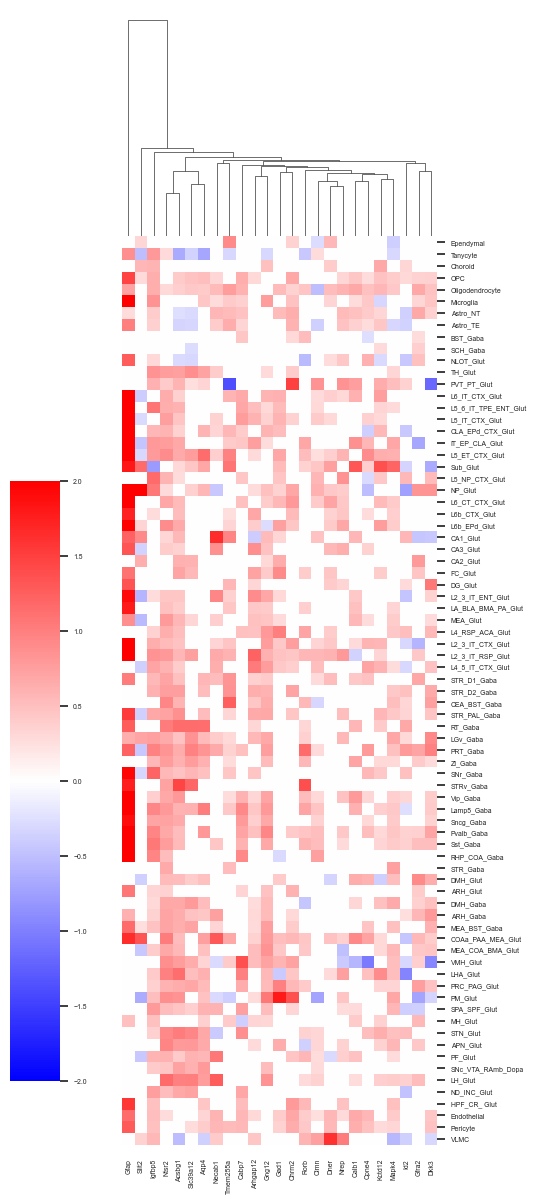

In [82]:
sns.set_theme(font_scale=.45)
heatmap = sns.clustermap(fdf, cmap = "bwr",
                center = 0, vmin = -2, vmax = 2,
                figsize=(5,12),
                cbar_pos=(-0.05,0.1,0.1,0.5),
                row_cluster=False)
from module.misc import save_figure
save_figure(heatmap,'top_DEG_heatmap',name_dir,format="svg")
# plt.savefig(f'Gallery/{today}/top_DEG_heatmap.svg', transparent = True, dpi=300, format='svg')

## Quantif

In [33]:
df_deg_quant = []
expressed = [len(df_expressed[key]) for key in df_filter.keys()]
deg_quant = [len(df_filter[key]) for key in df_filter.keys()]
deg_up = [len(df_filter[key][df_filter[key]['logfoldchanges'] > 0]) for key in df_filter.keys()]
deg_down = [len(df_filter[key][df_filter[key]['logfoldchanges'] < 0]) for key in df_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Celltype' : df_filter.keys(),
                                    'Expressed' : expressed,
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Celltype']
df_deg_quant

,Celltype,Expressed,nb_DEG,Upregulated,Downregulated
Celltype,,,,,
VMH_Glut,VMH_Glut,105,71,43,28
ARH_Gaba,ARH_Gaba,105,36,29,7
VLMC,VLMC,102,70,38,32
ZI_Gaba,ZI_Gaba,118,46,32,14
DMH_Gaba,DMH_Gaba,119,47,36,11
...,...,...,...,...,...
APN_Glut,APN_Glut,110,37,27,10
PVT_PT_Glut,PVT_PT_Glut,108,83,40,43
BST_Gaba,BST_Gaba,126,27,7,20


In [34]:
df_expressed.keys()

dict_keys(['VMH_Glut', 'ARH_Gaba', 'VLMC', 'ZI_Gaba', 'DMH_Gaba', 'Endothelial', 'ARH_Glut', 'Tanycyte', 'Oligodendrocyte', 'SC_Glut', 'DMH_Glut', 'Astro_NT', 'TH_Glut', 'LHA_Glut', 'Microglia', 'OPC', 'Ependymal', 'PRC_PAG_Glut', 'PF_Glut', 'LA_BLA_BMA_PA_Glut', 'Astro_TE', 'MEA_COA_BMA_Glut', 'MEA_BST_Gaba', 'Lamp5_Gaba', 'STR_PAL_Gaba', 'RT_Gaba', 'STN_Glut', 'L2_3_IT_ENT_Glut', 'COAa_PAA_MEA_Glut', 'L5_6_IT_TPE_ENT_Glut', 'Pvalb_Gaba', 'L4_5_IT_CTX_Glut', 'L2_3_IT_CTX_Glut', 'Vip_Gaba', 'Sncg_Gaba', 'L5_ET_CTX_Glut', 'Choroid', 'STR_D1_Gaba', 'IT_EP_CLA_Glut', 'CLA_EPd_CTX_Glut', 'L6_CT_CTX_Glut', 'CEA_BST_Gaba', 'STR_D2_Gaba', 'Sst_Gaba', 'STRv_Gaba', 'MEA_Glut', 'Pericyte', 'MH_Glut', 'LH_Glut', 'L5_IT_CTX_Glut', 'L5_NP_CTX_Glut', 'L6b_EPd_Glut', 'SPA_SPF_Glut', 'L6b_CTX_Glut', 'CA3_Glut', 'DG_Glut', 'CA1_Glut', 'L2_3_IT_RSP_Glut', 'L6_IT_CTX_Glut', 'L4_RSP_ACA_Glut', 'HPF_CR_ Glut', 'PRT_Gaba', 'PM_Glut', 'MM_Glut', 'CA2_Glut', 'STR_Gaba', 'SC_Gaba', 'FC_Glut', 'RHP_COA_Gaba', '

In [35]:
set1 = set(df_deg_quant['Celltype'].unique())
set1

{'APN_Glut',
 'ARH_Gaba',
 'ARH_Glut',
 'Astro_NT',
 'Astro_TE',
 'BST_Gaba',
 'CA1_Glut',
 'CA2_Glut',
 'CA3_Glut',
 'CEA_BST_Gaba',
 'CLA_EPd_CTX_Glut',
 'COAa_PAA_MEA_Glut',
 'Choroid',
 'DG_Glut',
 'DMH_Gaba',
 'DMH_Glut',
 'Endothelial',
 'Ependymal',
 'FC_Glut',
 'HPF_CR_ Glut',
 'IT_EP_CLA_Glut',
 'L2_3_IT_CTX_Glut',
 'L2_3_IT_ENT_Glut',
 'L2_3_IT_RSP_Glut',
 'L4_5_IT_CTX_Glut',
 'L4_RSP_ACA_Glut',
 'L5_6_IT_TPE_ENT_Glut',
 'L5_ET_CTX_Glut',
 'L5_IT_CTX_Glut',
 'L5_NP_CTX_Glut',
 'L6_CT_CTX_Glut',
 'L6_IT_CTX_Glut',
 'L6b_CTX_Glut',
 'L6b_EPd_Glut',
 'LA_BLA_BMA_PA_Glut',
 'LGv_Gaba',
 'LHA_Glut',
 'LH_Glut',
 'Lamp5_Gaba',
 'MEA_BST_Gaba',
 'MEA_COA_BMA_Glut',
 'MEA_Glut',
 'MH_Glut',
 'Microglia',
 'ND_INC_Glut',
 'NLOT_Glut',
 'NP_Glut',
 'OPC',
 'Oligodendrocyte',
 'PF_Glut',
 'PM_Glut',
 'PRC_PAG_Glut',
 'PRT_Gaba',
 'PVT_PT_Glut',
 'Pericyte',
 'Pvalb_Gaba',
 'RHP_COA_Gaba',
 'RT_Gaba',
 'SCH_Gaba',
 'SNc_VTA_RAmb_Dopa',
 'SNr_Gaba',
 'SPA_SPF_Glut',
 'STN_Glut',
 'STR_D1_

In [36]:
df_deg_quant['cell_class'] = 'Neuronal'
from module.misc import cell_class
dict_type = dict(zip(df_deg_quant['Celltype'],df_deg_quant['cell_class']))
dict_temp = cell_class()
dict_type.update(dict_temp)
df_deg_quant['cell_class'] = df_deg_quant['Celltype'].map(dict_type)
df_deg_quant


,Celltype,Expressed,nb_DEG,Upregulated,Downregulated,cell_class
Celltype,,,,,,
VMH_Glut,VMH_Glut,105,71,43,28,Neuronal
ARH_Gaba,ARH_Gaba,105,36,29,7,Neuronal
VLMC,VLMC,102,70,38,32,Vascular
ZI_Gaba,ZI_Gaba,118,46,32,14,Neuronal
DMH_Gaba,DMH_Gaba,119,47,36,11,Neuronal
...,...,...,...,...,...,...
APN_Glut,APN_Glut,110,37,27,10,Neuronal
PVT_PT_Glut,PVT_PT_Glut,108,83,40,43,Neuronal
BST_Gaba,BST_Gaba,126,27,7,20,Neuronal


In [37]:
### Region only, remove liminal celltypes
# df_deg_quant.drop(['VLMC', "Ependymal","Choroid",'Tanycyte'], axis = 0, inplace=True)

### Celltypes only, remove tanycyte
# df_deg_quant.drop(['Tanycyte'], axis = 0, inplace=True)

In [38]:
# order_list = ['STR D2 Gaba', 'STR D1 Gaba', 'DG Glut', 'CA1 ProS Glut', 'CA2 FC IG Glut', 'CA3 Glut',
#                'LSX Gaba', 'CEA Gaba', 'STR PAL Gaba', 'COAa PAA MEA Glut', 'NLOT Glut', 'L2 3 IT PIR ENTl Glut',
#                  'CLA EPd CTX Glut', 'L6 CT CTX Glut', 'L6b CTX Glut', 'L5 NP CTX Glut', 'L5 ET CTX Glut',
#                    'L2 3 IT RSP Glut', 'L4 5 IT CTX Glut', 'L6 IT CTX Glut', 'Lamp5 Gaba', 'Vip Gaba', 'Sncg Gaba',
#                      'Sst Gaba', 'STR Gaba', 'Pvalb Gaba', 'RT ZI Gaba', 'AD Glut', 'PT Glut', 'RE Glut', 'CM Glut',
#                        'SMT Glut', 'VP Glut', 'LD Glut', 'VM MD Glut', 'AV Glut', 'MH Glut', 'TRS BAC Glut', 'BAC Glut',
#                          'MPO Glut', 'PAL STR Gaba Chol', 'PVT Glut', 'MEA Glut', 'BST Glut', 'SPA Glut', 'AHN Glut',
#                            'LHA Glut', 'LH Glut', 'PVH Glut', 'SCH Gaba', 'DG PIR Ex IMN', 'OB STR CTX IMN', 'Microglia',
#                              'Endothelial', 'SMC','Pericyte', 'Choroid', 'ABC', 'VLMC', 'Tanycyte', 'Ependymal',
#                                'Astro TE', 'OPC', 'Oligodendrocyte']
# order_list = ['Oligodendrocyte', 'OPC', 'Astro NT', 'Astro TE', 'Ependymal', 'Pineal Glut', 'Tanycyte', 'CHOR', 'VLMC', 'Endothelial', 'Pericyte', 'Microglia', 'CA1 ProS Glut', 'CA2 FC IG Glut', 'CA3 Glut', 'DG Glut', 'L23 PIR ENTl Glut', 'MEA Glut', 'LA Glut', 'NLOT Glut', 'L23 CTX Glut', 'L23 RSP Glut', 'L4 CTX Glut', 'L6 CTX Glut', 'L5 CTX Glut', 'SUB ProS Glut', 'L6b CTX Glut', 'AD Glut', 'AV Glut', 'TH Glut', 'SN Dopa', 'LHA Glut', 'MB Glut', 'PAG Glut', 'HY Glut', 'LH Glut', 'VMH Glut', 'MM Glut', 'PVT Glut', 'PF Glut', 'APN Glut', 'SC Glut', 'MH Glut', 'BST Glut', 'LSX Gaba', 'SCH Gaba', 'Sst Gaba', 'MEA Gaba', 'BST Gaba', 'HY GABA', 'ARH GABA', 'Lamp5 Gaba', 'Vip Gaba', 'STR Gaba', 'STRv PAL Gaba', 'LGv Gaba', 'PRT Gaba', 'SC Gaba', 'ZI Gaba', 'SN Gaba', 'RT ZI GABA', 'Pvalb Gaba', 'STR D1D2 Gaba']

#circa-SD
order_list = ['Oligodendrocyte', 'Microglia', 'Choroid', 'ABC', 'VLMC', 'OB_STR_CTX_Inh_IMN', 'Ependymal', 'Tanycyte', 'OPC', 'Astrocyte', 'Endothelial', 'Pericyte', 'PVH_SO_Glut', 'PVR_Gaba', 'SCH_Gaba', 'MH_Glut', 'TRS_BAC_Glut', 'DG_PIR_Ex_IMN', 'HPF_CR_Glut', 'LSX_Gaba', 'CEA_AAA_BST_Gaba', 'STR_PAL_Gaba', 'Sst_Gaba', 'Lamp5_Gaba', 'Vip_Gaba', 'Pvalb_Gaba', 'STR_Gaba', 'RT_ZI_Gaba', 'SI_Gaba', 'ATN_Glut', 'PT_Glut', 'RE_Glut', 'AD_Glut', 'AV_Glut', 'TH_Glut', 'LSX_Glut', 'BST_MPN_Gaba', 'COAa_PAA_MEA_Glut', 'PAL_STR_Gaba_Chol', 'PVT_Glut', 'BST_po_Glut', 'LH_Glut', 'MEA_Glut', 'AHN_Glut', 'LHA_Glut', 'STR_D1_Gaba', 'STR_D2_Gaba', 'DG_Glut', 'CA1_ProS_Glut', 'CA2_FC_IG_Glut', 'CA3_Glut', 'L2_3_IT_CTX_Glut', 'L4_5_IT_CTX_Glut', 'L4_RSP_ACA_Glut', 'L2_3_IT_RSP_Glut', 'L5_ET_CTX_Glut', 'L5_NP_CTX_Glut', 'L6_IT_CTX_Glut', 'L6_CT_CTX_Glut', 'L6b_CTX_Glut', 'CLA_EPd_CTX_Glut', 'L2_3_IT_PIR_ENTl_Glut', 'NLOT_Glut']

### C123
order_list=['L6_IT_CTX_Glut', 'L5_6_IT_TPE_ENT_Glut', 'L5_IT_CTX_Glut', 'CLA_EPd_CTX_Glut', 'IT_EP_CLA_Glut', 'L5_ET_CTX_Glut', 'Sub_Glut', 'L5_NP_CTX_Glut', 'NP_Glut', 'L6_CT_CTX_Glut', 'L6b_CTX_Glut', 'L6b_EPd_Glut', 'CA1_Glut', 'CA3_Glut', 'CA2_Glut', 'FC_Glut', 'DG_Glut', 'L2_3_IT_ENT_Glut', 'LA_BLA_BMA_PA_Glut', 'MEA_Glut', 'L4_RSP_ACA_Glut', 'L2_3_IT_CTX_Glut', 'L2_3_IT_RSP_Glut', 'L4_5_IT_CTX_Glut', 'STR_D1_Gaba', 'STR_D2_Gaba', 'CEA_BST_Gaba', 'STR_PAL_Gaba', 'RT_Gaba', 'SC_Gaba', 'LGv_Gaba', 'PRT_Gaba', 'ZI_Gaba', 'SNr_Gaba', 'STRv_Gaba', 'Vip_Gaba', 'Lamp5_Gaba', 'Sncg_Gaba', 'Pvalb_Gaba', 'Sst_Gaba', 'RHP_COA_Gaba', 'STR_Gaba', 'DMH_Glut', 'ARH_Glut', 'DMH_Gaba', 'ARH_Gaba', 'MEA_BST_Gaba', 'COAa_PAA_MEA_Glut', 'MEA_COA_BMA_Glut', 'VMH_Glut', 'LHA_Glut', 'PRC_PAG_Glut', 'PM_Glut', 'SPA_SPF_Glut', 'MH_Glut', 'MM_Glut', 'PVH_SO_PVa_Glut', 'STN_Glut', 'APN_Glut', 'SC_Glut', 'PF_Glut', 'SNc_VTA_RAmb_Dopa', 'LH_Glut', 'ND_INC_Glut', 'TH_Glut', 'OPC', 'Oligodendrocyte', 'Microglia', 'Endothelial', 'Pericyte', 'Ependymal', 'Hypendymal', 'Pineal_Glut', 'Tanycyte', 'Choroid', 'VLMC', 'HPF_CR_ Glut', 'Astro_NT', 'Astro_TE']

### combined
order_list = ["BST_Gaba","SCH_Gaba","Endothelial","Pericyte","NLOT_Glut","OPC","TH_Glut","Oligodendrocyte","PVT_PT_Glut","L6_IT_CTX_Glut","L5_6_IT_TPE_ENT_Glut","L5_IT_CTX_Glut","CLA_EPd_CTX_Glut","IT_EP_CLA_Glut","L5_ET_CTX_Glut","Sub_Glut","L5_NP_CTX_Glut","NP_Glut","L6_CT_CTX_Glut","L6b_CTX_Glut","L6b_EPd_Glut","CA1_Glut","CA3_Glut","CA2_Glut","FC_Glut","DG_Glut","L2_3_IT_ENT_Glut","LA_BLA_BMA_PA_Glut","MEA_Glut","L4_RSP_ACA_Glut","L2_3_IT_CTX_Glut","L2_3_IT_RSP_Glut","L4_5_IT_CTX_Glut","Microglia","Ependymal","Hypendymal","Pineal_Glut","Tanycyte","Choroid","VLMC","HPF_CR_ Glut","Astro_NT","Astro_TE","STR_D1_Gaba","STR_D2_Gaba","CEA_BST_Gaba","STR_PAL_Gaba","RT_Gaba","SC_Gaba","LGv_Gaba","PRT_Gaba","ZI_Gaba","SNr_Gaba","STRv_Gaba","Vip_Gaba","Lamp5_Gaba","Sncg_Gaba","Pvalb_Gaba","Sst_Gaba","RHP_COA_Gaba","STR_Gaba","DMH_Glut","ARH_Glut","DMH_Gaba","ARH_Gaba","MEA_BST_Gaba","COAa_PAA_MEA_Glut","MEA_COA_BMA_Glut","VMH_Glut","LHA_Glut","PRC_PAG_Glut","PM_Glut","SPA_SPF_Glut","MH_Glut","MM_Glut","PVH_SO_PVa_Glut","STN_Glut","APN_Glut","SC_Glut","PF_Glut","SNc_VTA_RAmb_Dopa","LH_Glut","ND_INC_Glut"]

df_deg_quant["Celltype_order"] = pd.Categorical(df_deg_quant["Celltype"], categories=order_list, ordered = True)
df_deg_quant.sort_values(['cell_class','Celltype_order'], inplace= True)
df_deg_quant.dropna(axis = 0, inplace= True)

In [39]:
max(max(df_deg_quant['Upregulated']),max(df_deg_quant['Downregulated']))

52

In [40]:
set2 = set(df_deg_quant.Celltype.unique())

In [41]:
df_deg_quant

,Celltype,Expressed,nb_DEG,Upregulated,Downregulated,cell_class,Celltype_order
Celltype,,,,,,,
Ependymal,Ependymal,94,31,19,12,Ependymal,Ependymal
Tanycyte,Tanycyte,86,32,18,14,Ependymal,Tanycyte
Choroid,Choroid,88,39,34,5,Ependymal,Choroid
OPC,OPC,118,42,34,8,Glial,OPC
Oligodendrocyte,Oligodendrocyte,96,61,51,10,Glial,Oligodendrocyte
...,...,...,...,...,...,...,...
LH_Glut,LH_Glut,106,40,28,12,Neuronal,LH_Glut
ND_INC_Glut,ND_INC_Glut,105,32,19,13,Neuronal,ND_INC_Glut
Endothelial,Endothelial,103,47,34,13,Vascular,Endothelial


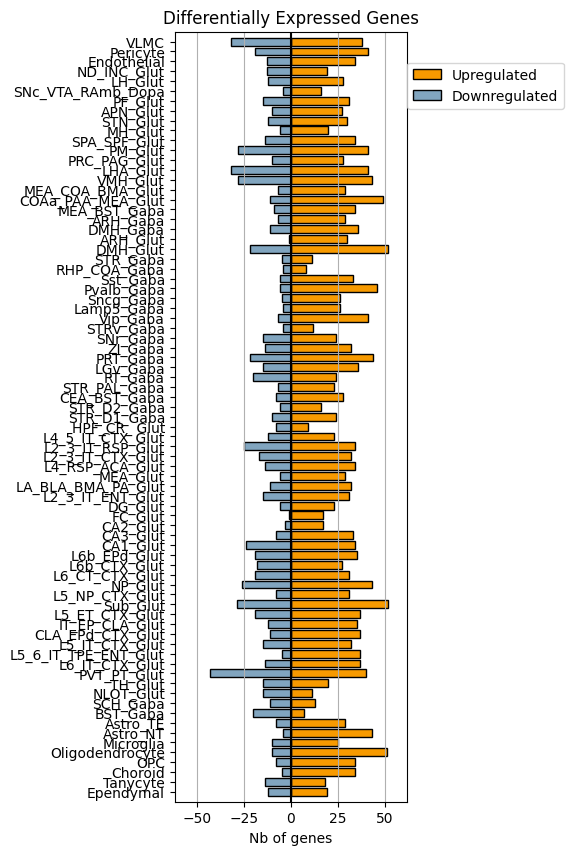

In [42]:
import matplotlib.pyplot as plt


fig = plt.figure(figsize=(3,10))
# df_deg_quant.sort_values(by='Downregulated', inplace=True)
# plt.barh(y = df_deg_quant["Celltype_order"].astype(str), width=df_deg_quant['Expressed'], height = 0.8, color =[], edgecolor = 'black', label = 'Expressed')
plt.barh(y = df_deg_quant["Celltype_order"].astype(str), width=df_deg_quant['Upregulated'], color = "#f79a00ff" , height = 0.8, edgecolor = 'black', label = "Upregulated")
plt.barh(y = df_deg_quant["Celltype_order"].astype(str), width=-df_deg_quant['Downregulated'],color = "#81a5bfff", height = 0.8, edgecolor = 'black', label = 'Downregulated')
plt.vlines(x=0, ymin=-1,ymax=len(df_deg_quant), color = 'black')
plt.legend(loc=(1,0.9))
plt.xlim((max(max(df_deg_quant['Upregulated']),max(df_deg_quant['Downregulated']))*-1)-10, max(max(df_deg_quant['Upregulated']),max(df_deg_quant['Downregulated']))+10)
plt.ylim(-1,len(df_deg_quant))
plt.title(f'Differentially Expressed Genes')
plt.xlabel("Nb of genes")
plt.grid(axis="x")

save_figure(fig, "DEG_per_celltype",name_dir, format="svg")
# plt.savefig(f'Gallery/{today}/DEG_per_celltype.svg', dpi = 300, format = "svg",transparent = True)

In [ ]:
cell_class_to_plot = 'Ependymal'
df_quant_temp = df_deg_quant[df_deg_quant['cell_class']==cell_class_to_plot]

# plt.figure(figsize=(3,10))
plt.barh(y = df_quant_temp["Celltype_order"].astype(str), width=df_quant_temp['Upregulated'], color = "#f79a00ff" , height = 0.8, edgecolor = 'black', label = "Upregulated")
plt.barh(y = df_quant_temp["Celltype_order"].astype(str), width=-df_quant_temp['Downregulated'],color = "#81a5bfff", height = 0.8, edgecolor = 'black', label = 'Downregulated')
plt.vlines(x=0, ymin=-1,ymax=len(df_quant_temp), color = 'black')
plt.legend(loc=(1,0.9))
plt.xlim((max(max(df_quant_temp['Upregulated']),max(df_quant_temp['Downregulated']))*-1)-10, max(max(df_quant_temp['Upregulated']),max(df_quant_temp['Downregulated']))+10)
plt.ylim(-1,len(df_quant_temp))
plt.title(f'Differentially Expressed Genes')
plt.xlabel("Nb of genes")
plt.grid(axis="x")
# plt.savefig(f'Gallery/{today}/DEG_per_celltype.svg', dpi = 300, format = "svg",transparent = True)

## Volcano plot

In [ ]:
df_filter.keys()

In [ ]:
key = 'Choroid'
threshold_text = 1e-10

plt.figure(figsize=(10,10))
plt.vlines(x=(-0.26,0.26), ymin=df_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')

plt.scatter(x=df_all[key]['logfoldchanges'], y = df_all[key]['pvals_adj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= df_filter[key]['logfoldchanges'], y=df_filter[key]['pvals_adj'], s=5, alpha=1, color = 'red')
for idx, gene in enumerate(df_filter[key][df_filter[key]['pvals_adj']< threshold_text]['names']):
    plt.text(df_filter[key][df_filter[key]['pvals_adj']< threshold_text]['logfoldchanges'][idx],
    df_filter[key][df_filter[key]['pvals_adj']< threshold_text]['pvals_adj'][idx]*0.55, str(gene), color = 'black', fontsize = 8, ha= 'center')
plt.yscale('log')
plt.xlim(-1,1)
plt.ylim(0,100000)
plt.gca().invert_yaxis()
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
plt.title(f"DEG: {key} - Whole Brain")
# plt.savefig(f'Gallery/{today}/volcano_plot_{key}.svg')

In [ ]:
df_filter[key].index = df_filter[key]['names']

## DEG all celltypes in one region

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

name_dir = 'all-samples-C123'
directory_DEG = f'{dir_processed}/analysis/{name_dir}/foldchanges/celltype_in_region'
region_of_interest = 'MEA'

df_all = pd.read_excel(f'{directory_DEG}/{region_of_interest}_all_celltypes_DEG.xlsx', sheet_name=None)

In [ ]:
test_grp = 'APP'

df_expressed = {}
for key in df_all.keys():
    if test_grp in df_all[key]["group"].unique():
        df_all[key] = df_all[key][df_all[key]['group'] == test_grp]
    df_expressed[key] = df_all[key][(df_all[key]['pct_nz_group']>0.1)& (df_all[key]['pct_nz_reference'] > 0.1) & df_all[key]['mean_count']>= 0.2]
    df_all[key].index = df_all[key]['names']

In [ ]:
df_filter = {}
for key in df_all.keys():
    df_filter[key] = df_all[key][(df_all[key]['pvals_adj'] < 0.05)
                                 & (df_all[key]['pct_nz_group'] > 0.1)
                                 & (df_all[key]['pct_nz_reference'] > 0.1)
                                 & (abs(df_all[key]['logfoldchanges']) > 0.26)
                                 & (df_all[key]['mean_count'] >= 0.2)
                                 ]

In [ ]:
df_filter['Vip_Gaba']

In [ ]:
df_deg_quant = []
expressed = [len(df_expressed[key]) for key in df_expressed.keys()]
deg_quant = [len(df_filter[key]) for key in df_filter.keys()]
deg_up = [len(df_filter[key][df_filter[key]['logfoldchanges'] > 0]) for key in df_filter.keys()]
deg_down = [len(df_filter[key][df_filter[key]['logfoldchanges'] < 0]) for key in df_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Celltype' : df_filter.keys(),
                                    'Expressed' : expressed,
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Celltype']
df_deg_quant = df_deg_quant[df_deg_quant["nb_DEG"] >= 5]
df_deg_quant.sort_values(by='nb_DEG', ascending = True, inplace=True)
df_deg_quant

In [ ]:
n_glut = [
#     "IT_EP_CLA_Glut", "L2_3_IT_CTX_Glut", "L2_3_IT_ENT_Glut", "L2_3_IT_RSP_Glut", "L4_5_IT_CTX_Glut", "L4_RSP_ACA_Glut", "L5_6_IT_TPE_ENT_Glut", 
# "L5_ET_CTX_Glut", "L5_IT_CTX_Glut", "L6_CT_CTX_Glut", "L6_IT_CTX_Glut", "L6b_CTX_Glut", "L6b_EPd_Glut",
#  'Pvalb_Gaba', 'Vip_Gaba', 'Sst_Gaba', 'Sncg_Gaba','Lamp5_Gaba',
# "Microglia", "Astro_TE", "OPC", "Oligodendrocyte",
# "Pericyte", "Endothelial",
 "SCH_Gaba", "Astro_TE"
 ]

set_n_glut = set()
set_nglut_down=set()

for idx, key in enumerate(df_all.keys()):
    temp_up = df_filter[key][df_filter[key]["logfoldchanges"]>0].sort_values(by='adjustpval', ascending = False)['names']
    temp_down = df_filter[key][df_filter[key]["logfoldchanges"]>0].sort_values(by='logfoldchanges', ascending = False)['names']
    if idx == 0:
        set_n_glut = set(temp_up)
        set_nglut_down = set(temp_down)
    else:
        set_n_glut = set_n_glut.union(temp_up)
        set_nglut_down = set_nglut_down.union(temp_down)
    # print(set_n_glut)

print(len(set_n_glut),len(set_nglut_down))
set_n_glut = set_n_glut.union(set_nglut_down)

In [ ]:
cluster_plot_neurons = pd.DataFrame(columns = df_all.keys(), index = list(set_n_glut), dtype = float)

for key in df_all.keys():
    for gene in set_n_glut:
        if gene in df_filter[key]['names'].values:
            cluster_plot_neurons.loc[gene, key]= df_filter[key].loc[gene, 'logfoldchanges']
        else:
            cluster_plot_neurons.loc[gene, key]=0

In [ ]:
sns.clustermap(cluster_plot_neurons, center = 0, cmap = 'bwr', figsize=(20,20)
               )

In [ ]:
df_filter.keys()

In [ ]:
plt.barh(y=df_deg_quant['Celltype'], width = df_deg_quant['Upregulated'])
plt.barh(y=df_deg_quant['Celltype'], width = -df_deg_quant['Downregulated'])


In [ ]:
key = 'Oligodendrocyte'

threshold_text = 0

min_thr = df_filter[key][df_filter[key]['pvals_adj'] != 0]['pvals_adj'].min()
df_filter[key]["-logQ"] = -np.log10(df_filter[key]["pvals_adj"].astype("float")+min_thr)
df_all[key]["-logQ"] = -np.log10(df_all[key]["pvals_adj"].astype("float")+min_thr)

plt.figure(figsize=(5,5))
plt.vlines(x=(-0.26,0.26), ymin=0, ymax=max(df_all[key]["-logQ"]), color = "black", linestyles='dashed', linewidth = 1)
plt.hlines(y=-np.log10(0.05), xmin=-1, xmax=1, color = "black", linestyles='dashed', linewidth = 1)
plt.scatter(x=df_all[key]['logfoldchanges'], y = df_all[key]["-logQ"], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= df_filter[key]['logfoldchanges'], y=df_filter[key]["-logQ"], s=5, alpha=1, color = 'red')

texts = []
for idx, gene in enumerate(df_filter[key][df_filter[key]["-logQ"]>threshold_text]['names']):
    texts.append(plt.text(df_filter[key][df_filter[key]["-logQ"]>threshold_text]["logfoldchanges"][idx],
            df_filter[key][df_filter[key]["-logQ"]>threshold_text]["-logQ"][idx],
            str(gene), color = 'black', fontsize = 8, ha= 'center'))
adjust_text(texts,arrowprops=dict(arrowstyle="-", color='black', lw=0.5))
# plt.yscale('log')
plt.xlim(-2,2)
# plt.ylim(0,0)
# plt.gca().invert_yaxis()
plt.xlabel('Log2 Foldchange')
plt.ylabel('-Log10 Adjusted p-value')
# plt.title(f"DEG: {key} - {region_of_interest}")
# plt.savefig(f'Gallery/{today}/volcano_plot_{key}_{region_of_interest}.svg', dpi= 300, transparent = True)

## DEG celltype in diff regions

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

name_dir = 'all-samples-combined'
dir_processed =  'D:/Jupyter_notebook/Xenium_jupyter_notebook'

directory_DEG = f'{dir_processed}/analysis/{name_dir}/foldchanges/neurotransmitter_in_region/'
all_regions = os.listdir(directory_DEG)

In [ ]:
all_regions =  [region for region in all_regions if region.split('_')[-1] == 'DEG.xlsx' ]
# all_regions.remove('Choroid_all_celltypes_DEG.xlsx')
# all_regions.remove('Ependymal_all_celltypes_DEG.xlsx')
# all_regions.remove('VLMC_all_celltypes_DEG.xlsx')
all_regions

In [ ]:
cell_type_inregion = "Dopamine"
celltype_inregion_DEG = {}
for file in all_regions:
    region = file.split("_")[0]
    print(region)
    df = pd.read_excel(f'{directory_DEG}{file}', sheet_name= None)
    # print(df.keys())
    if cell_type_inregion not in df.keys(): continue
    celltype_inregion_DEG[region] = df[cell_type_inregion]

In [ ]:
celltype_inregion_DEG = {key:val for key, val in celltype_inregion_DEG.items() if len(val)  > 1}

In [ ]:
exp_group = "APP"

for key in celltype_inregion_DEG.keys():
    celltype_inregion_DEG[key] = celltype_inregion_DEG[key][celltype_inregion_DEG[key]['group'] == exp_group]
    celltype_inregion_DEG[key].index = celltype_inregion_DEG[key]['names']

celltype_inregion_DEG_filter = {}

for key in celltype_inregion_DEG.keys():
    celltype_inregion_DEG_filter[key] = celltype_inregion_DEG[key][(celltype_inregion_DEG[key]['pvals_adj'] < 0.05)
                                           & (celltype_inregion_DEG[key]['pct_nz_group'] > 0.1)
                                           & (abs(celltype_inregion_DEG[key]['logfoldchanges']) > 0.26)
                                           & (celltype_inregion_DEG[key]['mean_count'] > 0.2)
                                           ]

In [ ]:
deg_quant = [len(celltype_inregion_DEG_filter[key]) for key in celltype_inregion_DEG_filter.keys()]
deg_up = [len(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] > 0]) for key in celltype_inregion_DEG_filter.keys()]
deg_down = [len(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] < 0]) for key in celltype_inregion_DEG_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Region' : celltype_inregion_DEG_filter.keys(),
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Region']
# df_deg_quant.drop(['VLMC','Ependymal', "Choroid"], axis=0, inplace=True)
# df_deg_quant = df_deg_quant[df_deg_quant['nb_DEG'] > 10]

In [ ]:
plt.figure(figsize=(3,3))
df_deg_quant.sort_values(by='nb_DEG', inplace=True)
plt.barh(y = df_deg_quant['Region'], width=df_deg_quant['Upregulated'], edgecolor ='black')
plt.barh(y = df_deg_quant['Region'], width=-df_deg_quant['Downregulated'], edgecolor ='black')
plt.vlines(x=0, ymin=-1,ymax=len(df_deg_quant), color = 'black', linestyles='dashed')
plt.ylim(-0.5, len(df_deg_quant)-0.5)
plt.title(f'DEG: {cell_type_inregion} in different regions')
# plt.savefig(f'Gallery/{today}/{name_dir}_{cell_type_inregion}_quant.svg', transparent = True, dpi = 300, format = "svg")

In [ ]:
# celltype_inregion_DEG_filter['SCH'].sort_values(by="logfoldchanges")

In [ ]:
key = 'SN'

plt.figure(figsize=(5,5))
plt.vlines(x=(-0.26,0.26), ymin=celltype_inregion_DEG_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')

plt.scatter(x=celltype_inregion_DEG[key]['logfoldchanges'], y = celltype_inregion_DEG[key]['pvals_adj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= celltype_inregion_DEG_filter[key]['logfoldchanges'], y=celltype_inregion_DEG_filter[key]['pvals_adj'], s=5, alpha=1, color = 'red')
for idx, gene in enumerate(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['pvals_adj']< 1e-5]['names']):
    plt.text(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['pvals_adj']< 1e-5]['logfoldchanges'][idx],
             celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['pvals_adj']< 1e-5]['pvals_adj'][idx]*0.55,
             str(gene), color = 'black', fontsize = 8, ha= 'center')
plt.yscale('log')
plt.xlim(-2,2)
# plt.ylim(0,50)
plt.gca().invert_yaxis()
plt.title(f'DEG: {cell_type_inregion} in {key}')
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
# plt.savefig(f'Gallery/{today}/volcano_plot_{cell_type_inregion}_in_{key}.svg')

In [ ]:
# list_genes = set()
# for key in celltype_inregion_DEG_filter.keys():
#     print(key)
#     temp = set(celltype_inregion_DEG_filter[key].sort_values['names'].values)
#     list_genes.update(temp)
# len(list_genes)


In [ ]:
top_list_genes = set()
for key in celltype_inregion_DEG_filter.keys():
    print(key)
    temp_up = set(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] > 0].sort_values(by='logfoldchanges', ascending = False)['names'].values[0:5])
    temp_down = set(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] < 0].sort_values(by='logfoldchanges', ascending = True)['names'].values[0:5])
    top_list_genes.update(temp_up, temp_down)
len(top_list_genes)


In [ ]:
print(top_list_genes)

In [ ]:
cluster_plot_neurons = pd.DataFrame(columns = df_deg_quant['Region'].unique(), index = list(top_list_genes), dtype = float)

for key in df_deg_quant['Region'].unique():
    # print(key)
    for gene in top_list_genes:
        # print(gene)
        if gene in celltype_inregion_DEG_filter[key]['names'].values:
            cluster_plot_neurons.loc[gene, key]= celltype_inregion_DEG_filter[key].loc[gene, 'logfoldchanges']
        else:
            cluster_plot_neurons.loc[gene, key]=0

In [ ]:
sns.set(font_scale=0.5)
sns.clustermap(cluster_plot_neurons, center = 0, cmap = 'bwr', figsize=(3,8),col_cluster=True
               )
# plt.savefig(f'Gallery/{today}/{name_dir}_{cell_type_inregion}_heatmap.svg', dpi=300, transparent = True, format = 'svg')

## GO analysis

### Pre-process

In [ ]:
## Download ontologies from http://geneontology.org/ontology/go-basic.obo
## Download associations from ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/gene2go.gz

from goatools.base import download_go_basic_obo
from goatools.base import download_ncbi_associations
from goatools.obo_parser import GODag
from goatools.anno.genetogo_reader import Gene2GoReader

# obo_fname = download_go_basic_obo()
fin_gene2go = download_ncbi_associations()
obodag = GODag("go-basic.obo")



In [ ]:
# Read NCBI's gene2go. Store annotations in a list of namedtuples

objanno = Gene2GoReader(fin_gene2go, taxids=[10090])
ns2assoc = objanno.get_ns2assc()

for nspc, id2gos in ns2assoc.items():
    print("{NS} {N:,} annotated mouse genes".format(NS=nspc, N=len(id2gos)))

In [ ]:
from module.genes_ncbi_mouse_proteincoding import GENEID2NT as GeneID2nt_mouse

print(len(GeneID2nt_mouse))

In [ ]:
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.05, # default significance cut-off
        methods = ['fdr_bh']) # defult multipletest correction method



In [ ]:
## Get all the go items including those appears multiple times

GO_items = []

temp = goeaobj.ns2objgoea['BP'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['CC'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['MF'].assoc
for item in temp:
    GO_items += temp[item]

In [ ]:
## Build mapping dictionaries between gene id and gene symbols

id_mapper = {}

for key_2 in GeneID2nt_mouse:
    id_mapper[GeneID2nt_mouse[key_2].Symbol] = GeneID2nt_mouse[key_2].GeneID
    
rev_mapper = {v: k for k, v in id_mapper.items()} 

In [ ]:
import numpy as np

def go_analysis(gene_list):
    
    mapped_gene = []

    for gene in gene_list:
        try:
            mapped_gene.append(id_mapper[gene])
        except:
            pass 
    
    goea_results_all = goeaobj.run_study(mapped_gene)  
    
    goea_results_sig = [r for r in goea_results_all if r.p_fdr_bh<0.05]
    
    
    df_go = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

    df_go = df_go[df_go.n_genes > 1]
    df_go['LogP'] = -np.log10(df_go['p'])
    return df_go

### Process

#### DEG

In [ ]:
key = 'Choroid'

In [ ]:
target_genes_up = list(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] > 0]['names'])
target_genes_down = list(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] < 0]['names'])

In [ ]:
target_genes_up = list(df_filter[key][df_filter[key]['logfoldchanges'] > 0]['names'])
target_genes_down = list(df_filter[key][df_filter[key]['logfoldchanges'] < 0]['names'])

In [ ]:
print(target_genes_up)

In [ ]:
target_genes_up = [id_mapper[gene] for gene in target_genes_up if gene in id_mapper]
target_genes_down = [id_mapper[gene] for gene in target_genes_down if gene in id_mapper]



goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.05, # default significance cut-off
        methods = ['fdr_bh']) # defult multipletest correction methodgoea_results_all = goeaobj.run_study()

goea_results_up = goeaobj.run_study(target_genes_up)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_up = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

goea_results_down = goeaobj.run_study(target_genes_down)
goea_results_down_sig = [r for r in goea_results_down if r.p_fdr_bh<0.01]

df_go_down = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_down_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

                        

#### Cycling genes

In [ ]:
### Alternative Cycling genes
target_genes_NS = NS_cyc
target_genes_NS = [id_mapper[gene] for gene in target_genes_NS if gene in id_mapper]

target_genes_SD = SD_cyc
target_genes_SD = [id_mapper[gene] for gene in target_genes_SD if gene in id_mapper]

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.1, # default significance cut-off
        methods = ['fdr_bh']) # default multiple test correction method

goea_results_up = goeaobj.run_study(target_genes_NS)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_NS = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

goea_results_up = goeaobj.run_study(target_genes_SD)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_SD = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

df_go_NS.head(15), df_go_SD.head(15)

#### Alternative list of genes

In [ ]:
list_gen = ddf_table[ddf_table['ratio_UNASSIGNED']>0.5]['Unnamed: 0'].values
print(*list_gen)

In [ ]:
### Alternative list of genes
target_genes_list = list_gen
target_genes_list = [id_mapper[gene] for gene in target_genes_list if gene in id_mapper]

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of mouse protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.1, # default significance cut-off
        methods = ['fdr_bh']) # default multiple test correction method

goea_results_up = goeaobj.run_study(target_genes_list)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_list = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])



df_go_list.head(15)

### GO plot

In [ ]:
df_go_down.head(5)
len(df_go_up)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap

plt.figure(figsize=(4,6),dpi=300)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams["font.size"] = 10

if min(len(df_go_up), len(df_go_down)) > 7:
    n_g = 8
else:
    n_g = min(len(df_go_up), len(df_go_down))

up_labels = [s for s in df_go_up['term'][0:n_g]][::-1]
up_ngenes = [s for s in df_go_up['n_genes'][0:n_g]][::-1]
up_pvalues = [-np.log10(p) for p in df_go_up['p_corr'][0:n_g]][::-1]
up_ycor = [0.1*n for n in range(1,len(up_labels)+1)]

down_labels = [s for s in df_go_down['term'][0:n_g]][::-1]
down_ngenes = [s for s in df_go_down['n_genes'][0:n_g]][::-1]
down_pvalues = [-np.log10(p) for p in df_go_down['p_corr'][0:n_g]][::-1]
down_ycor = [0.1*n for n in range(len(down_labels)+1,len(down_labels)+len(up_labels)+1)]

#print(len(y_cor),len(labels),len(p_values))

plt.barh(up_ycor,up_pvalues,height=0.05, color = 'blue', label = 'Upregulated')

plt.barh(down_ycor,down_pvalues,height=0.05, color = 'red', label = 'Downregulated')

plt.yticks(up_ycor+down_ycor,[textwrap.fill(e,40) for e in up_labels+down_labels],fontsize=8)

for x,gene in enumerate(up_ngenes):
    plt.text(up_pvalues[x] + 0.5, up_ycor[x]-0.01, gene, color = 'black', fontsize = 8, ha= 'center')

for x,gene in enumerate(down_ngenes):
    plt.text(down_pvalues[x] + 0.5, down_ycor[x]-0.01, gene, color = 'black', fontsize = 8, ha= 'center')

#plt.yticks()
plt.xticks([0,3.0,6.0])
plt.xlabel('-log10(p_value)')
# plt.ylim(0,n_g)

plt.savefig(f'Gallery/{today}/GO_{key}.svg',format = "svg", dpi=300,transparent = True, bbox_inches='tight')

# plt.savefig(f'Gallery/{today}/GO_{region_of_interest}_{key}.svg',format = "svg", dpi=300,transparent = True, bbox_inches='tight')
plt.legend(markerscale=20, bbox_to_anchor=(1.02, 1), loc='lower left', borderaxespad=0)
plt.show()

In [ ]:
df_go_down

In [ ]:
filename_ = 'plaque_up'

df = pd.read_csv(f'data/Metascape/{filename_}.csv')
df.sample(1)
len(df)

In [ ]:
plt.figure(figsize=(3,4))
plt.scatter(x=df['logP'], y=df['GO'], s=df['nb_gene']**2, cmap='viridis')

for idx, go in enumerate(df['GO'].unique()):
    plt.hlines(y=df['GO'][idx], xmin=df['logP'][idx]+0.2, xmax=0, color = 'black', linestyle = 'dashed') 

plt.xlabel('Log p-value')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

plt.savefig(f'Gallery/{today}/GO_{filename_}.svg', transparent= True, dpi=300)